# BraTS 2020 Dataset Download and Exploration


## 1. Install Packages

In [2]:
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from tqdm.auto import tqdm

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

/home/danishzaheer/miniconda3/envs/foundation_AI/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Project Paths

In [3]:
PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / 'data'
RAW_ROOT = DATA_ROOT / 'raw'
PROCESSED_ROOT = DATA_ROOT / 'processed'
DATASET_LINK = DATA_ROOT / 'brats2020'

KAGGLE_DATASET = 'awsaf49/brats20-dataset-training-validation'

RAW_ROOT.mkdir(parents=True, exist_ok=True)
PROCESSED_ROOT.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('Raw data folder:', RAW_ROOT)
print('Processed data folder:', PROCESSED_ROOT)
print('Stable dataset path:', DATASET_LINK)

Project root: /home/danishzaheer/Deep_learning_project
Raw data folder: /home/danishzaheer/Deep_learning_project/data/raw
Processed data folder: /home/danishzaheer/Deep_learning_project/data/processed
Stable dataset path: /home/danishzaheer/Deep_learning_project/data/brats2020


## 4. Download Dataset

In [4]:
download_path = Path(
    kagglehub.dataset_download(
        KAGGLE_DATASET,
        output_dir=str(RAW_ROOT),
    )
).resolve()

print('KaggleHub returned:', download_path)

def find_dataset_root(download_path, raw_root):
    for root in [download_path, raw_root]:
        if (root / 'BraTS2020_TrainingData').exists():
            return root

    for root in [download_path, raw_root]:
        for training_dir in root.rglob('BraTS2020_TrainingData'):
            return training_dir.parent

    raise FileNotFoundError('Could not find BraTS2020_TrainingData after download.')


DATASET_ROOT = find_dataset_root(download_path, RAW_ROOT)
print('Dataset root used in this notebook:', DATASET_ROOT)

if DATASET_LINK.is_symlink():
    DATASET_LINK.unlink()

if not DATASET_LINK.exists():
    try:
        DATASET_LINK.symlink_to(DATASET_ROOT, target_is_directory=True)
        print('Created symlink:', DATASET_LINK, '->', DATASET_ROOT)
    except OSError as error:
        print('Could not create symlink. Using DATASET_ROOT directly.')
        print(error)

KaggleHub returned: /home/danishzaheer/Deep_learning_project/data/raw
Dataset root used in this notebook: /home/danishzaheer/Deep_learning_project/data/raw
Created symlink: /home/danishzaheer/Deep_learning_project/data/brats2020 -> /home/danishzaheer/Deep_learning_project/data/raw


## 5. Check Folder Structure

In [5]:
def show_tree(root, max_depth=3, max_items=100):
    shown = 0

    for path in sorted(root.rglob('*')):
        rel = path.relative_to(root)
        depth = len(rel.parts)

        if depth > max_depth:
            continue

        prefix = '  ' * (depth - 1)
        kind = '[DIR] ' if path.is_dir() else '[FILE]'
        print(prefix + kind, path.name)
        shown += 1

        if shown >= max_items:
            print('... output limited ...')
            break


show_tree(DATASET_ROOT)

[DIR]  .complete
  [DIR]  datasets
    [DIR]  awsaf49
[DIR]  BraTS2020_TrainingData
  [DIR]  MICCAI_BraTS2020_TrainingData
    [DIR]  BraTS20_Training_001
    [DIR]  BraTS20_Training_002
    [DIR]  BraTS20_Training_003
    [DIR]  BraTS20_Training_004
    [DIR]  BraTS20_Training_005
    [DIR]  BraTS20_Training_006
    [DIR]  BraTS20_Training_007
    [DIR]  BraTS20_Training_008
    [DIR]  BraTS20_Training_009
    [DIR]  BraTS20_Training_010
    [DIR]  BraTS20_Training_011
    [DIR]  BraTS20_Training_012
    [DIR]  BraTS20_Training_013
    [DIR]  BraTS20_Training_014
    [DIR]  BraTS20_Training_015
    [DIR]  BraTS20_Training_016
    [DIR]  BraTS20_Training_017
    [DIR]  BraTS20_Training_018
    [DIR]  BraTS20_Training_019
    [DIR]  BraTS20_Training_020
    [DIR]  BraTS20_Training_021
    [DIR]  BraTS20_Training_022
    [DIR]  BraTS20_Training_023
    [DIR]  BraTS20_Training_024
    [DIR]  BraTS20_Training_025
    [DIR]  BraTS20_Training_026
    [DIR]  BraTS20_Training_027
    [DIR]  Br

## 6. Discover NIfTI Files

In [6]:
MODALITIES = ['flair', 't1', 't1ce', 't2']
ALL_TYPES = MODALITIES + ['seg']

nii_files = sorted(list(DATASET_ROOT.rglob('*.nii')) + list(DATASET_ROOT.rglob('*.nii.gz')))

print('Total NIfTI files found:', len(nii_files))
for path in nii_files[:8]:
    print(path.relative_to(DATASET_ROOT))

Total NIfTI files found: 2345
BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001_flair.nii
BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001_seg.nii
BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001_t1.nii
BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001_t1ce.nii
BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001_t2.nii
BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_002/BraTS20_Training_002_flair.nii
BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_002/BraTS20_Training_002_seg.nii
BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_002/BraTS20_Training_002_t1.nii


## 7. Build Case Table

In [7]:
def get_file_type(path):
    name = path.name.lower()

    for file_type in ['flair', 't1ce', 't1', 't2', 'seg']:
        if name.endswith('_' + file_type + '.nii') or name.endswith('_' + file_type + '.nii.gz'):
            return file_type

    return None


def get_split_from_folder(folder):
    text = ' '.join([folder.name] + [parent.name for parent in folder.parents]).lower()

    if 'validation' in text:
        return 'challenge_validation'
    if 'training' in text or 'train' in text:
        return 'training'

    return 'unknown'


case_rows = []
case_folders = sorted({path.parent for path in nii_files})

for folder in case_folders:
    files = {}

    for path in sorted(folder.glob('*.nii*')):
        file_type = get_file_type(path)
        if file_type is not None:
            files[file_type] = path

    if len(files) == 0:
        continue

    row = {
        'case_id': folder.name,
        'source_split': get_split_from_folder(folder),
        'case_folder': str(folder),
    }

    for file_type in ALL_TYPES:
        row[file_type + '_path'] = str(files.get(file_type, ''))
        row['has_' + file_type] = file_type in files

    row['has_all_modalities'] = all(row['has_' + modality] for modality in MODALITIES)
    case_rows.append(row)

case_df = pd.DataFrame(case_rows).sort_values(['source_split', 'case_id']).reset_index(drop=True)

all_cases_csv_path = PROCESSED_ROOT / 'brats2020_all_cases.csv'
case_df.to_csv(all_cases_csv_path, index=False)

print('Total cases found:', len(case_df))
display(case_df[['case_id', 'source_split', 'has_all_modalities', 'has_seg']].head())
display(case_df.groupby('source_split').agg(cases=('case_id', 'count'), labeled_cases=('has_seg', 'sum')).reset_index())
print('Saved all-case table:', all_cases_csv_path)

Total cases found: 494


,case_id,source_split,has_all_modalities,has_seg
0,BraTS20_Validation_001,challenge_validation,True,False
1,BraTS20_Validation_002,challenge_validation,True,False
2,BraTS20_Validation_003,challenge_validation,True,False
3,BraTS20_Validation_004,challenge_validation,True,False
4,BraTS20_Validation_005,challenge_validation,True,False


,source_split,cases,labeled_cases
0,challenge_validation,125,0
1,training,369,368


Saved all-case table: /home/danishzaheer/Deep_learning_project/data/processed/brats2020_all_cases.csv


## 8. Training vs Challenge Validation Summary

In [8]:
training_cases_df = case_df[case_df['source_split'] == 'training'].copy()
challenge_validation_cases_df = case_df[case_df['source_split'] == 'challenge_validation'].copy()
labeled_training_cases_df = training_cases_df[training_cases_df['has_all_modalities'] & training_cases_df['has_seg']].copy()
missing_seg_training_cases_df = training_cases_df[training_cases_df['has_all_modalities'] & (~training_cases_df['has_seg'])].copy()

summary_df = pd.DataFrame([
    {
        'group': 'training cases',
        'count': len(training_cases_df),
    },
    {
        'group': 'challenge validation cases',
        'count': len(challenge_validation_cases_df),
    },
    {
        'group': 'labeled training cases for supervised learning',
        'count': len(labeled_training_cases_df),
    },
    {
        'group': 'training cases missing seg',
        'count': len(missing_seg_training_cases_df),
    },
])

display(summary_df)

if len(missing_seg_training_cases_df) > 0:
    print('Training cases missing segmentation:')
    display(missing_seg_training_cases_df[['case_id', 'case_folder']])

challenge_validation_csv_path = PROCESSED_ROOT / 'brats2020_challenge_validation_cases.csv'
challenge_validation_cases_df.to_csv(challenge_validation_csv_path, index=False)
print('Saved challenge validation case list:', challenge_validation_csv_path)

,group,count
0,training cases,369
1,challenge validation cases,125
2,labeled training cases for supervised learning,368
3,training cases missing seg,1


Training cases missing segmentation:


,case_id,case_folder
479,BraTS20_Training_355,/home/danishzaheer/Deep_learning_project/data/...


Saved challenge validation case list: /home/danishzaheer/Deep_learning_project/data/processed/brats2020_challenge_validation_cases.csv


## 9. Load CSV Metadata If Present

In [9]:
csv_files = sorted(DATASET_ROOT.rglob('*.csv'))
print('CSV files found:', len(csv_files))

for path in csv_files:
    print('\nCSV:', path.relative_to(DATASET_ROOT))
    temp_df = pd.read_csv(path)
    print('Shape:', temp_df.shape)
    display(temp_df.head())

CSV files found: 4

CSV: BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/name_mapping.csv
Shape: (369, 6)


,Grade,BraTS_2017_subject_ID,BraTS_2018_subject_ID,TCGA_TCIA_subject_ID,BraTS_2019_subject_ID,BraTS_2020_subject_ID
0,HGG,Brats17_CBICA_AAB_1,Brats18_CBICA_AAB_1,NaN,BraTS19_CBICA_AAB_1,BraTS20_Training_001
1,HGG,Brats17_CBICA_AAG_1,Brats18_CBICA_AAG_1,NaN,BraTS19_CBICA_AAG_1,BraTS20_Training_002
2,HGG,Brats17_CBICA_AAL_1,Brats18_CBICA_AAL_1,NaN,BraTS19_CBICA_AAL_1,BraTS20_Training_003
3,HGG,Brats17_CBICA_AAP_1,Brats18_CBICA_AAP_1,NaN,BraTS19_CBICA_AAP_1,BraTS20_Training_004
4,HGG,Brats17_CBICA_ABB_1,Brats18_CBICA_ABB_1,NaN,BraTS19_CBICA_ABB_1,BraTS20_Training_005



CSV: BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/survival_info.csv
Shape: (236, 4)


,Brats20ID,Age,Survival_days,Extent_of_Resection
0,BraTS20_Training_001,60.463,289,GTR
1,BraTS20_Training_002,52.263,616,GTR
2,BraTS20_Training_003,54.301,464,GTR
3,BraTS20_Training_004,39.068,788,GTR
4,BraTS20_Training_005,68.493,465,GTR



CSV: BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/name_mapping_validation_data.csv
Shape: (125, 5)


,BraTS_2017_subject_ID,BraTS_2018_subject_ID,TCGA_TCIA_subject_ID,BraTS_2019_subject_ID,BraTS_2020_subject_ID
0,Brats17_CBICA_AAM_1,Brats18_CBICA_AAM_1,NaN,BraTS19_CBICA_AAM_1,BraTS20_Validation_001
1,Brats17_CBICA_ABT_1,Brats18_CBICA_ABT_1,NaN,BraTS19_CBICA_ABT_1,BraTS20_Validation_002
2,Brats17_CBICA_ALA_1,Brats18_CBICA_ALA_1,NaN,BraTS19_CBICA_ALA_1,BraTS20_Validation_003
3,Brats17_CBICA_ALT_1,Brats18_CBICA_ALT_1,NaN,BraTS19_CBICA_ALT_1,BraTS20_Validation_004
4,Brats17_CBICA_ALV_1,Brats18_CBICA_ALV_1,NaN,BraTS19_CBICA_ALV_1,BraTS20_Validation_005



CSV: BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/survival_evaluation.csv
Shape: (29, 3)


,BraTS20ID,Age,ResectionStatus
0,BraTS20_Validation_001,68.170,GTR
1,BraTS20_Validation_002,50.153,GTR
2,BraTS20_Validation_004,21.726,GTR
3,BraTS20_Validation_006,55.482,GTR
4,BraTS20_Validation_007,64.753,GTR


## 10. Inspect One Labeled Training Case

In [10]:
sample_case = labeled_training_cases_df.iloc[0]

print('Sample case:', sample_case['case_id'])
print('Source split:', sample_case['source_split'])
print('Has segmentation:', sample_case['has_seg'])

Sample case: BraTS20_Training_001
Source split: training
Has segmentation: True


In [11]:
def load_nifti_array(path, dtype=np.float32):
    image = nib.load(path)
    array = np.asanyarray(image.dataobj).astype(dtype)
    return image, array


arrays = {}
headers = {}

for modality in MODALITIES:
    image_object, array = load_nifti_array(sample_case[modality + '_path'], dtype=np.float32)
    arrays[modality] = array
    headers[modality] = image_object

image_object, array = load_nifti_array(sample_case['seg_path'], dtype=np.uint8)
arrays['seg'] = array
headers['seg'] = image_object

info_rows = []

for name, array in arrays.items():
    image_object = headers[name]
    info_rows.append({
        'name': name,
        'shape': array.shape,
        'dtype': str(array.dtype),
        'spacing': image_object.header.get_zooms()[:3],
        'min': float(array.min()),
        'max': float(array.max()),
    })

display(pd.DataFrame(info_rows))
print('Unique segmentation labels:', np.unique(arrays['seg']))

,name,shape,dtype,spacing,min,max
0,flair,"(240, 240, 155)",float32,"(1.0, 1.0, 1.0)",0.0,625.0
1,t1,"(240, 240, 155)",float32,"(1.0, 1.0, 1.0)",0.0,678.0
2,t1ce,"(240, 240, 155)",float32,"(1.0, 1.0, 1.0)",0.0,1845.0
3,t2,"(240, 240, 155)",float32,"(1.0, 1.0, 1.0)",0.0,376.0
4,seg,"(240, 240, 155)",uint8,"(1.0, 1.0, 1.0)",0.0,4.0


Unique segmentation labels: [0 1 2 4]


## 11. BraTS Segmentation Labels

In [12]:
def make_region_masks(seg):
    wt = np.isin(seg, [1, 2, 4]).astype(np.uint8)
    tc = np.isin(seg, [1, 4]).astype(np.uint8)
    et = (seg == 4).astype(np.uint8)
    return {'WT': wt, 'TC': tc, 'ET': et}


region_masks = make_region_masks(arrays['seg'])

region_summary = []
for region_name, mask in region_masks.items():
    region_summary.append({
        'region': region_name,
        'positive_voxels': int(mask.sum()),
        'positive_percent': float(mask.mean() * 100),
    })

display(pd.DataFrame(region_summary))

,region,positive_voxels,positive_percent
0,WT,211979,2.374317
1,TC,43185,0.483703
2,ET,27742,0.310730


## 12. Visualize MRI Modalities

Slice selected for visualization: 67


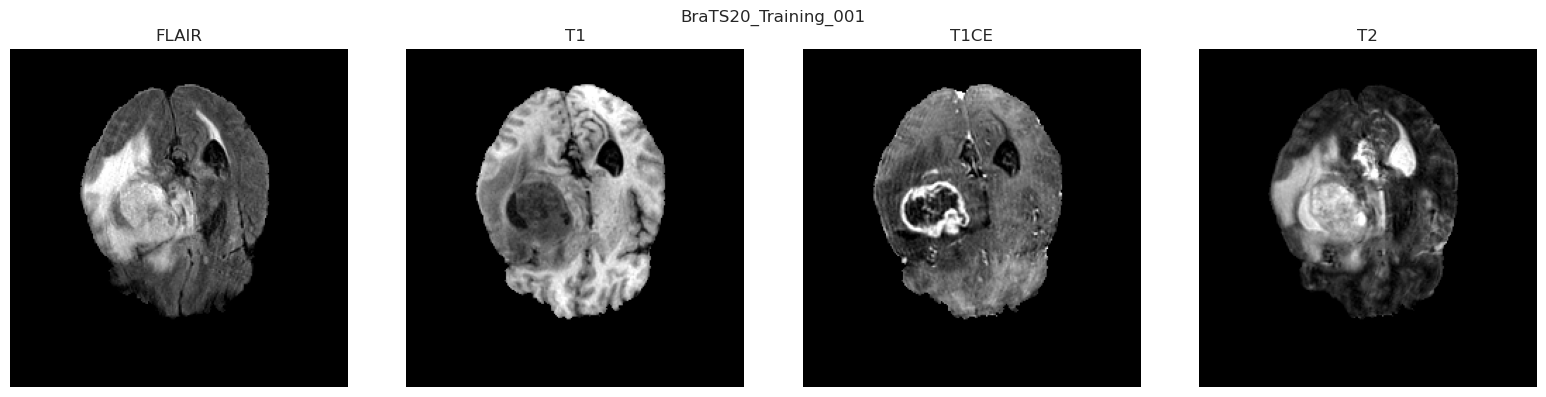

In [13]:
def normalize_nonzero(slice_2d):
    values = slice_2d.astype(np.float32)
    nonzero = values[values > 0]

    if nonzero.size == 0:
        return values

    low, high = np.percentile(nonzero, [1, 99])
    return np.clip((values - low) / (high - low + 1e-6), 0, 1)


tumor_pixels_per_slice = (arrays['seg'] > 0).sum(axis=(0, 1))
slice_index = int(np.argmax(tumor_pixels_per_slice))
print('Slice selected for visualization:', slice_index)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, modality in zip(axes, MODALITIES):
    current_slice = arrays[modality][:, :, slice_index]
    ax.imshow(normalize_nonzero(current_slice).T, cmap='gray', origin='lower')
    ax.set_title(modality.upper())
    ax.axis('off')

plt.suptitle(sample_case['case_id'])
plt.tight_layout()
plt.show()

## 13. Visualize Segmentation Regions

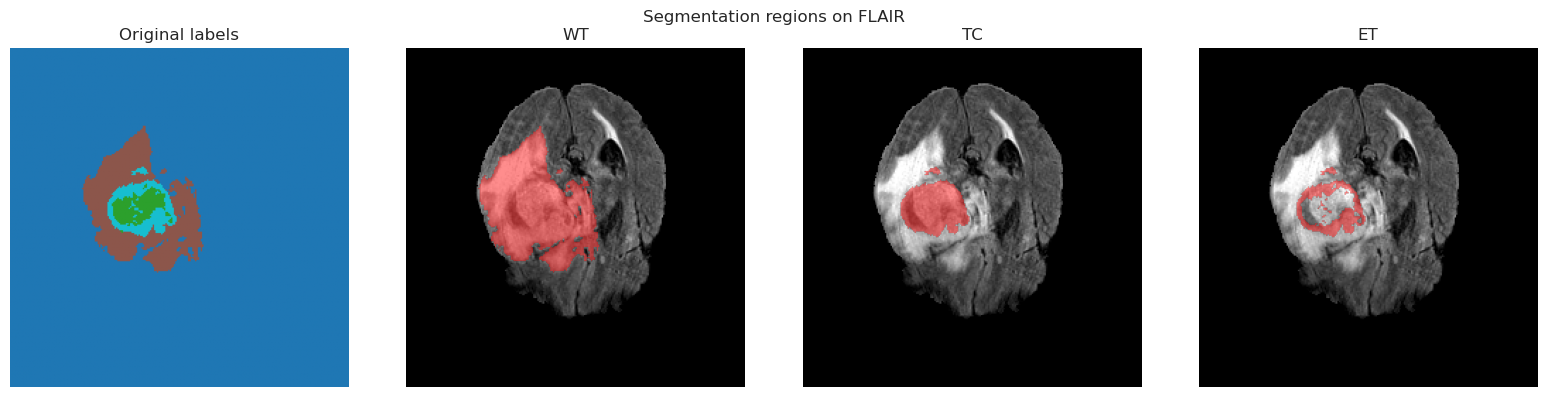

In [14]:
base_slice = normalize_nonzero(arrays['flair'][:, :, slice_index]).T

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(arrays['seg'][:, :, slice_index].T, cmap='tab10', origin='lower')
axes[0].set_title('Original labels')
axes[0].axis('off')

for ax, region_name in zip(axes[1:], ['WT', 'TC', 'ET']):
    mask_slice = region_masks[region_name][:, :, slice_index].T
    ax.imshow(base_slice, cmap='gray', origin='lower')
    ax.imshow(np.ma.masked_where(mask_slice == 0, mask_slice), cmap='autumn', alpha=0.45, origin='lower')
    ax.set_title(region_name)
    ax.axis('off')

plt.suptitle('Segmentation regions on FLAIR')
plt.tight_layout()
plt.show()

## 14. Dataset-Wide Shape and Spacing Check

In [15]:
shape_rows = []

for row in tqdm(case_df.itertuples(index=False), total=len(case_df), desc='Reading headers'):
    if not row.has_flair:
        continue

    image_object = nib.load(row.flair_path)
    shape_rows.append({
        'case_id': row.case_id,
        'source_split': row.source_split,
        'shape': image_object.shape,
        'spacing': image_object.header.get_zooms()[:3],
        'has_seg': row.has_seg,
    })

shape_df = pd.DataFrame(shape_rows)
display(shape_df.head())
display(shape_df.groupby(['source_split', 'shape', 'spacing']).size().reset_index(name='cases'))

Reading headers: 100%|██████████| 494/494 [00:00<00:00, 1093.17it/s]


,case_id,source_split,shape,spacing,has_seg
0,BraTS20_Validation_001,challenge_validation,"(240, 240, 155)","(1.0, 1.0, 1.0)",False
1,BraTS20_Validation_002,challenge_validation,"(240, 240, 155)","(1.0, 1.0, 1.0)",False
2,BraTS20_Validation_003,challenge_validation,"(240, 240, 155)","(1.0, 1.0, 1.0)",False
3,BraTS20_Validation_004,challenge_validation,"(240, 240, 155)","(1.0, 1.0, 1.0)",False
4,BraTS20_Validation_005,challenge_validation,"(240, 240, 155)","(1.0, 1.0, 1.0)",False


,source_split,shape,spacing,cases
0,challenge_validation,"(240, 240, 155)","(1.0, 1.0, 1.0)",125
1,training,"(240, 240, 155)","(1.0, 1.0, 1.0)",369


## 15. Label Imbalance In Training Masks

Counting labels: 100%|██████████| 40/40 [00:04<00:00,  9.33it/s]


,label,name,voxels,percent
0,0,background,353733075,99.051600
1,1,necrotic/non-enhancing core,452888,0.126817
2,2,edema,2360094,0.660869
3,4,enhancing tumor,573943,0.160714


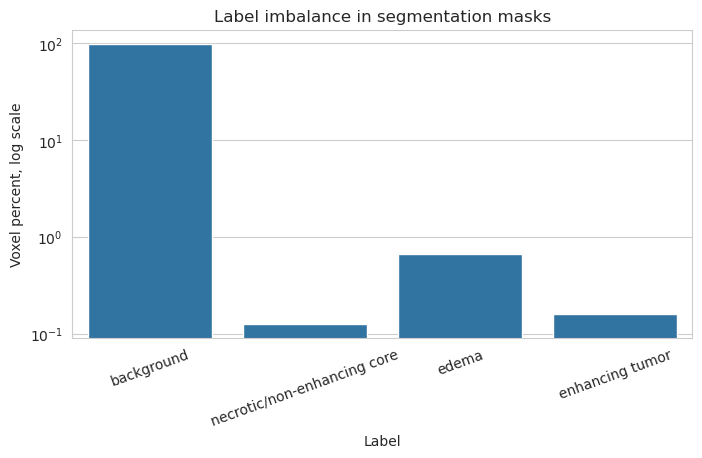

In [16]:
MAX_CASES_FOR_LABEL_STATS = min(40, len(labeled_training_cases_df))
label_stat_cases_df = labeled_training_cases_df.head(MAX_CASES_FOR_LABEL_STATS)

label_counts = {0: 0, 1: 0, 2: 0, 4: 0}

for row in tqdm(label_stat_cases_df.itertuples(index=False), total=len(label_stat_cases_df), desc='Counting labels'):
    seg = np.asanyarray(nib.load(row.seg_path).dataobj).astype(np.uint8)
    labels, counts = np.unique(seg, return_counts=True)

    for label, count in zip(labels, counts):
        label_counts[int(label)] = label_counts.get(int(label), 0) + int(count)

label_names = {
    0: 'background',
    1: 'necrotic/non-enhancing core',
    2: 'edema',
    4: 'enhancing tumor',
}

label_df = pd.DataFrame({
    'label': list(label_counts.keys()),
    'name': [label_names.get(label, 'unknown') for label in label_counts.keys()],
    'voxels': list(label_counts.values()),
})
label_df['percent'] = label_df['voxels'] / label_df['voxels'].sum() * 100

display(label_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=label_df, x='name', y='percent')
plt.yscale('log')
plt.title('Label imbalance in segmentation masks')
plt.xlabel('Label')
plt.ylabel('Voxel percent, log scale')
plt.xticks(rotation=20)
plt.show()

## 16. Intensity Statistics

Intensity stats: 100%|██████████| 20/20 [00:07<00:00,  2.81it/s]


,modality,mean,std,p01,p50,p99
0,flair,196.862669,78.940679,38.2,189.70,502.5
1,t1,346.324240,88.780464,120.3,351.95,517.8
2,t1ce,399.715553,121.761977,137.2,396.15,876.8
3,t2,336.619174,156.783617,120.6,291.80,910.9


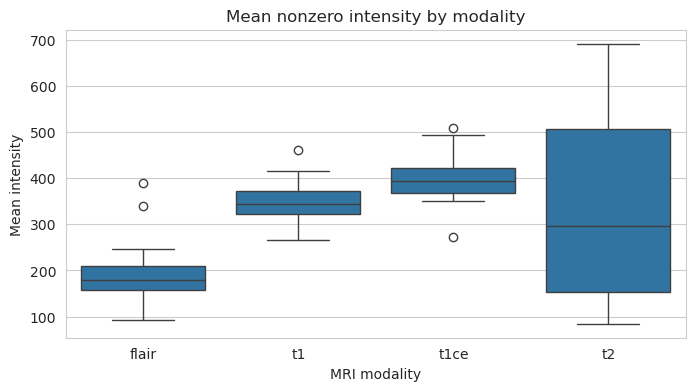

In [17]:
MAX_CASES_FOR_INTENSITY_STATS = min(20, len(case_df))
intensity_cases_df = case_df[case_df['has_all_modalities']].head(MAX_CASES_FOR_INTENSITY_STATS)
intensity_rows = []

for row in tqdm(intensity_cases_df.itertuples(index=False), total=len(intensity_cases_df), desc='Intensity stats'):
    for modality in MODALITIES:
        array = np.asanyarray(nib.load(getattr(row, modality + '_path')).dataobj).astype(np.float32)
        values = array[array > 0]

        if values.size == 0:
            continue

        intensity_rows.append({
            'case_id': row.case_id,
            'source_split': row.source_split,
            'modality': modality,
            'mean': float(values.mean()),
            'std': float(values.std()),
            'p01': float(np.percentile(values, 1)),
            'p50': float(np.percentile(values, 50)),
            'p99': float(np.percentile(values, 99)),
        })

intensity_df = pd.DataFrame(intensity_rows)
display(intensity_df.groupby('modality')[['mean', 'std', 'p01', 'p50', 'p99']].mean().reset_index())

plt.figure(figsize=(8, 4))
sns.boxplot(data=intensity_df, x='modality', y='mean')
plt.title('Mean nonzero intensity by modality')
plt.xlabel('MRI modality')
plt.ylabel('Mean intensity')
plt.show()

## 17. Optional Full 2D Slice Index

In [18]:
full_slice_rows = []
full_slice_cases_df = case_df[case_df['has_all_modalities']].copy()

for row in tqdm(full_slice_cases_df.itertuples(index=False), total=len(full_slice_cases_df), desc='Creating full slice index'):
    num_slices = nib.load(row.flair_path).shape[2]

    for slice_index in range(num_slices):
        full_slice_rows.append({
            'case_id': row.case_id,
            'source_split': row.source_split,
            'slice_index': slice_index,
            'flair_path': row.flair_path,
            't1_path': row.t1_path,
            't1ce_path': row.t1ce_path,
            't2_path': row.t2_path,
            'seg_path': row.seg_path,
            'has_seg': row.has_seg,
        })

full_slice_df = pd.DataFrame(full_slice_rows)
full_slice_csv_path = PROCESSED_ROOT / 'brats2020_full_2d_slice_index.csv'
full_slice_df.to_csv(full_slice_csv_path, index=False)

print('Total 2D slice rows across all complete cases:', len(full_slice_df))
print('Saved full slice index:', full_slice_csv_path)
display(full_slice_df[['case_id', 'source_split', 'slice_index', 'has_seg']].head())

Creating full slice index: 100%|██████████| 494/494 [00:00<00:00, 2446.50it/s]


Total 2D slice rows across all complete cases: 76570
Saved full slice index: /home/danishzaheer/Deep_learning_project/data/processed/brats2020_full_2d_slice_index.csv


,case_id,source_split,slice_index,has_seg
0,BraTS20_Validation_001,challenge_validation,0,False
1,BraTS20_Validation_001,challenge_validation,1,False
2,BraTS20_Validation_001,challenge_validation,2,False
3,BraTS20_Validation_001,challenge_validation,3,False
4,BraTS20_Validation_001,challenge_validation,4,False


## 18. Make Supervised Train/Valid/Test Splits

This is the split that should be used by your model notebooks. It uses only labeled training cases and splits by patient/case, not by slice.

In [19]:
TRAIN_RATIO = 0.70
VALID_RATIO = 0.15
TEST_RATIO = 0.15

if not np.isclose(TRAIN_RATIO + VALID_RATIO + TEST_RATIO, 1.0):
    raise ValueError('Train, valid, and test ratios must sum to 1.')

case_ids = labeled_training_cases_df['case_id'].to_numpy().copy()
rng = np.random.default_rng(42)
rng.shuffle(case_ids)

num_cases = len(case_ids)
num_train = int(round(TRAIN_RATIO * num_cases))
num_valid = int(round(VALID_RATIO * num_cases))
num_test = num_cases - num_train - num_valid

train_ids = set(case_ids[:num_train])
valid_ids = set(case_ids[num_train:num_train + num_valid])
test_ids = set(case_ids[num_train + num_valid:])

def assign_supervised_split(case_id):
    if case_id in train_ids:
        return 'train'
    if case_id in valid_ids:
        return 'valid'
    return 'test'


supervised_case_df = labeled_training_cases_df.copy()
supervised_case_df['supervised_split'] = supervised_case_df['case_id'].apply(assign_supervised_split)
supervised_case_df = supervised_case_df.sort_values(['supervised_split', 'case_id']).reset_index(drop=True)

supervised_case_csv_path = PROCESSED_ROOT / 'brats2020_supervised_case_splits.csv'
train_case_csv_path = PROCESSED_ROOT / 'brats2020_train_cases.csv'
valid_case_csv_path = PROCESSED_ROOT / 'brats2020_valid_cases.csv'
test_case_csv_path = PROCESSED_ROOT / 'brats2020_test_cases.csv'

supervised_case_df.to_csv(supervised_case_csv_path, index=False)
supervised_case_df[supervised_case_df['supervised_split'] == 'train'].to_csv(train_case_csv_path, index=False)
supervised_case_df[supervised_case_df['supervised_split'] == 'valid'].to_csv(valid_case_csv_path, index=False)
supervised_case_df[supervised_case_df['supervised_split'] == 'test'].to_csv(test_case_csv_path, index=False)

display(
    supervised_case_df['supervised_split']
    .value_counts()
    .rename_axis('supervised_split')
    .reset_index(name='cases')
)

supervised_slice_rows = []

for row in tqdm(supervised_case_df.itertuples(index=False), total=len(supervised_case_df), desc='Creating supervised slice index'):
    num_slices = nib.load(row.flair_path).shape[2]

    for slice_index in range(num_slices):
        supervised_slice_rows.append({
            'case_id': row.case_id,
            'supervised_split': row.supervised_split,
            'slice_index': slice_index,
            'flair_path': row.flair_path,
            't1_path': row.t1_path,
            't1ce_path': row.t1ce_path,
            't2_path': row.t2_path,
            'seg_path': row.seg_path,
        })

supervised_slice_df = pd.DataFrame(supervised_slice_rows)
supervised_slice_csv_path = PROCESSED_ROOT / 'brats2020_supervised_2d_slice_index.csv'
train_slice_csv_path = PROCESSED_ROOT / 'brats2020_train_slices.csv'
valid_slice_csv_path = PROCESSED_ROOT / 'brats2020_valid_slices.csv'
test_slice_csv_path = PROCESSED_ROOT / 'brats2020_test_slices.csv'

supervised_slice_df.to_csv(supervised_slice_csv_path, index=False)
supervised_slice_df[supervised_slice_df['supervised_split'] == 'train'].to_csv(train_slice_csv_path, index=False)
supervised_slice_df[supervised_slice_df['supervised_split'] == 'valid'].to_csv(valid_slice_csv_path, index=False)
supervised_slice_df[supervised_slice_df['supervised_split'] == 'test'].to_csv(test_slice_csv_path, index=False)

display(supervised_slice_df.groupby('supervised_split').size().reset_index(name='slices'))

print('Labeled training cases used for supervised splits:', len(supervised_case_df))
print('Challenge validation cases kept separate:', len(challenge_validation_cases_df))
print('Saved supervised case split:', supervised_case_csv_path)
print('Saved train cases:', train_case_csv_path)
print('Saved valid cases:', valid_case_csv_path)
print('Saved test cases:', test_case_csv_path)
print('Saved supervised 2D slice index:', supervised_slice_csv_path)
print('Saved train slices:', train_slice_csv_path)
print('Saved valid slices:', valid_slice_csv_path)
print('Saved test slices:', test_slice_csv_path)

,supervised_split,cases
0,train,258
1,test,55
2,valid,55


Creating supervised slice index: 100%|██████████| 368/368 [00:00<00:00, 2270.18it/s]


,supervised_split,slices
0,test,8525
1,train,39990
2,valid,8525


Labeled training cases used for supervised splits: 368
Challenge validation cases kept separate: 125
Saved supervised case split: /home/danishzaheer/Deep_learning_project/data/processed/brats2020_supervised_case_splits.csv
Saved train cases: /home/danishzaheer/Deep_learning_project/data/processed/brats2020_train_cases.csv
Saved valid cases: /home/danishzaheer/Deep_learning_project/data/processed/brats2020_valid_cases.csv
Saved test cases: /home/danishzaheer/Deep_learning_project/data/processed/brats2020_test_cases.csv
Saved supervised 2D slice index: /home/danishzaheer/Deep_learning_project/data/processed/brats2020_supervised_2d_slice_index.csv
Saved train slices: /home/danishzaheer/Deep_learning_project/data/processed/brats2020_train_slices.csv
Saved valid slices: /home/danishzaheer/Deep_learning_project/data/processed/brats2020_valid_slices.csv
Saved test slices: /home/danishzaheer/Deep_learning_project/data/processed/brats2020_test_slices.csv
